[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-2/chatbot-summarization.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239436-lesson-5-chatbot-w-summarizing-messages-and-memory)

# Chatbot with message summarization

## Review

We've covered how to customize graph state schema and reducer. 
 
We've also shown a number of ways to trim or filter messages in graph state. 

## Goals

Now, let's take it one step further! 

Rather than just trimming or filtering messages, we'll show how to use LLMs to produce a running summary of the conversation.
 
This allows us to retain a compressed representation of the full conversation, rather than just removing it with trimming or filtering.

We'll incorporate this summarization into a simple Chatbot.  

And we'll equip that Chatbot with memory, supporting long-running conversations without incurring high token cost / latency. 

In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain_groq

In [2]:
import os, httpx
from dotenv import load_dotenv

# Load .env using absolute path (override=True to ensure it always loads fresh)
load_dotenv("/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/langchain-academy/.env", override=True)

CA_BUNDLE = "/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/langchain-academy/ca-bundle.pem"
os.environ["SSL_CERT_FILE"] = CA_BUNDLE
os.environ["REQUESTS_CA_BUNDLE"] = CA_BUNDLE

# Create a custom httpx client with the CA bundle
http_client = httpx.Client(verify=CA_BUNDLE)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("GROQ_API_KEY")

We'll use [LangSmith](https://docs.smith.langchain.com/) for [tracing](https://docs.smith.langchain.com/concepts/tracing).

In [3]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

In [4]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")

We'll use `MessagesState`, as before.

In addition to the built-in `messages` key, we'll now include a custom key (`summary`).

In [5]:
from langgraph.graph import MessagesState
class State(MessagesState):
    summary: str

We'll define a node to call our LLM that incorporates a summary, if it exists, into the prompt.

In [6]:
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage

# Define the logic to call the model
def call_model(state: State):
    
    # Get summary if it exists
    summary = state.get("summary", "")

    # If there is summary, then we add it
    if summary:
        
        # Add summary to system message
        system_message = f"Summary of conversation earlier: {summary}"

        # Append summary to any newer messages
        messages = [SystemMessage(content=system_message)] + state["messages"]
    
    else:
        messages = state["messages"]
    
    response = llm.invoke(messages)
    return {"messages": response}

We'll define a node to produce a summary.

Note, here we'll use `RemoveMessage` to filter our state after we've produced the summary.

In [7]:
def summarize_conversation(state: State):
    
    # First, we get any existing summary
    summary = state.get("summary", "")

    # Create our summarization prompt 
    if summary:
        
        # A summary already exists
        summary_message = (
            f"This is summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into account the new messages above:"
        )
        
    else:
        summary_message = "Create a summary of the conversation above:"

    # Add prompt to our history
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    response = llm.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

We'll add a conditional edge to determine whether to produce a summary based on the conversation length.

In [14]:
from langgraph.graph import END
from typing_extensions import Literal
# Determine whether to end or summarize the conversation
def should_continue(state: State) -> Literal ["summarize conversation",END]:
    
    """Return the next node to execute."""
    
    messages = state["messages"]
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize conversation"
    
    # Otherwise we can just end
    return END

## Adding memory

Recall that [state is transient](https://github.com/langchain-ai/langgraph/discussions/352#discussioncomment-9291220) to a single graph execution.

This limits our ability to have multi-turn conversations with interruptions. 

As introduced at the end of Module 1, we can use [persistence](https://langchain-ai.github.io/langgraph/how-tos/persistence/) to address this! 
 
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update. 

As we previously showed, one of the easiest to work with is `MemorySaver`, an in-memory key-value store for Graph state.

All we need to do is compile the graph with a checkpointer, and our graph has memory!

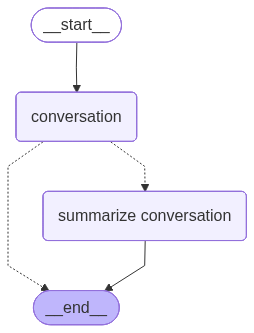

In [15]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START

# Define a new graph
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node("summarize conversation", summarize_conversation)

# Set the entrypoint as conversation
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize conversation", END)

# Compile
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

## Threads

The checkpointer saves the state at each step as a checkpoint.

These saved checkpoints can be grouped into a `thread` of conversation.

Think about Slack as an analog: different channels carry different conversations.

Threads are like Slack channels, capturing grouped collections of state (e.g., conversation).

Below, we use `configurable` to set a thread ID.

![state.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbadf3b379c2ee621adfd1_chatbot-summarization1.png)

In [16]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}

# Start conversation
input_message = HumanMessage(content="hi! I'm Lance")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages']:
    m.pretty_print()
print("-----Done-----")
input_message = HumanMessage(content="what's my name?")
output = graph.invoke({"messages": [input_message]}, config) 

for m in output['messages']:
    m.pretty_print()
print("-----Done-----")

input_message = HumanMessage(content="i like the 49ers!")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages']:
    m.pretty_print()
print("-----Done-----")

================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

<think>
Okay, the user said hi and introduced himself as Lance. I should respond with a friendly greeting, acknowledge his introduction, and ask how I can assist him. Keep it welcoming and open-ended.
</think>

Hi Lance! Nice to meet you! How can I assist you today? 😊
-----Done-----
================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

<think>
Okay, the user said hi and introduced himself as Lance. I should respond with a friendly greeting, acknowledge his introduction, and ask how I can assist him. Keep it welcoming and open-ended.
</think>

Hi Lance! Nice to meet you! How can I assist you today? 😊
================================ Human Message =================================

what's my

Now, we don't yet have a summary of the state because we still have < = 6 messages.

This was set in `should_continue`. 

```
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return "summarize_conversation"
```

We can pick up the conversation because we have the thread.

In [17]:
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content="hi! I'm Lance", additional_kwargs={}, response_metadata={}, id='d09d6580-7ad8-4a55-b819-a8e9082b1c9b'), AIMessage(content='<think>\nOkay, the user said hi and introduced himself as Lance. I should respond with a friendly greeting, acknowledge his introduction, and ask how I can assist him. Keep it welcoming and open-ended.\n</think>\n\nHi Lance! Nice to meet you! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 13, 'total_tokens': 74, 'completion_time': 0.125429272, 'completion_tokens_details': None, 'prompt_time': 0.000397543, 'prompt_tokens_details': None, 'queue_time': 0.047680785, 'total_time': 0.125826815}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cb79f-b65c-7033-9d6a-29e9abdc519c-0', tool_calls=[], inv

In [18]:
graph.get_state(config).values.get("summary","")

''

The `config` with thread ID allows us to proceed from the previously logged state!

In [19]:
input_message = HumanMessage(content="i like Nick Bosa, isn't he the highest paid defensive player?")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages']:
    m.pretty_print()

================================ Human Message =================================

i like Nick Bosa, isn't he the highest paid defensive player?
================================== Ai Message ==================================

<think>
Okay, let's break down the user's question. They mentioned liking Nick Bosa and asked if he's the highest-paid defensive player. First, I need to confirm the current contracts of top defensive players in the NFL.

I know that Nick Bosa has a significant contract with the 49ers. I recall that in 2023, he signed a four-year, $135 million deal, making him one of the highest-paid defenders. But I should check if there are others who might surpass him. Players like Aaron Donald, Justin Houston, and others might have higher deals. 

Wait, Aaron Donald signed a three-year, $110 million contract with the Rams. That's a lot, but not as high as Bosa's deal. Then there's Justin Houston with the Chiefs, who had a $28.5 million payout in 2023, but that's not the total 

In [20]:
graph.get_state(config).values.get("summary","")

"<think>\nOkay, let's see. The user is Lance, and he's a 49ers fan. He mentioned liking Nick Bosa and asked if he's the highest-paid defensive player. I need to summarize the conversation.\n\nFirst, I should start by stating Lance's introduction and his team. Then, mention his interest in Bosa. I should highlight the contract details I provided, like the $135 million over four years and the $65 million guaranteed. Also, compare him to other top-paid players like Aaron Donald and Justin Houston. Make sure to clarify that while Bosa is top-paid, Donald has the highest guaranteed. \n\nI need to keep it concise, but include all key points. Maybe end with a question about his favorite Bosa moment to encourage further interaction. Check for any numbers or names I might have missed. Make sure the summary flows naturally and accurately reflects the conversation.\n</think>\n\n**Summary of the Conversation:**  \nLance introduced himself as a 49ers fan and expressed admiration for Nick Bosa. The 

## LangSmith

Let's review the trace!